In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
RAW = PROJECT_ROOT / "data" / "raw"

app = pd.read_csv(RAW / "application_train.csv")
print(app.shape)
app["TARGET"].value_counts(normalize=True)

(307511, 122)


TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64

In [2]:
missing = app.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(app) * 100).round(2)
missing_summary = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_summary[missing_summary["missing_pct"] > 0].head(20)

,missing_count,missing_pct
COMMONAREA_AVG,214865,69.87
COMMONAREA_MODE,214865,69.87
COMMONAREA_MEDI,214865,69.87
NONLIVINGAPARTMENTS_MEDI,213514,69.43
NONLIVINGAPARTMENTS_MODE,213514,69.43
NONLIVINGAPARTMENTS_AVG,213514,69.43
FONDKAPREMONT_MODE,210295,68.39
LIVINGAPARTMENTS_AVG,210199,68.35
LIVINGAPARTMENTS_MEDI,210199,68.35
LIVINGAPARTMENTS_MODE,210199,68.35


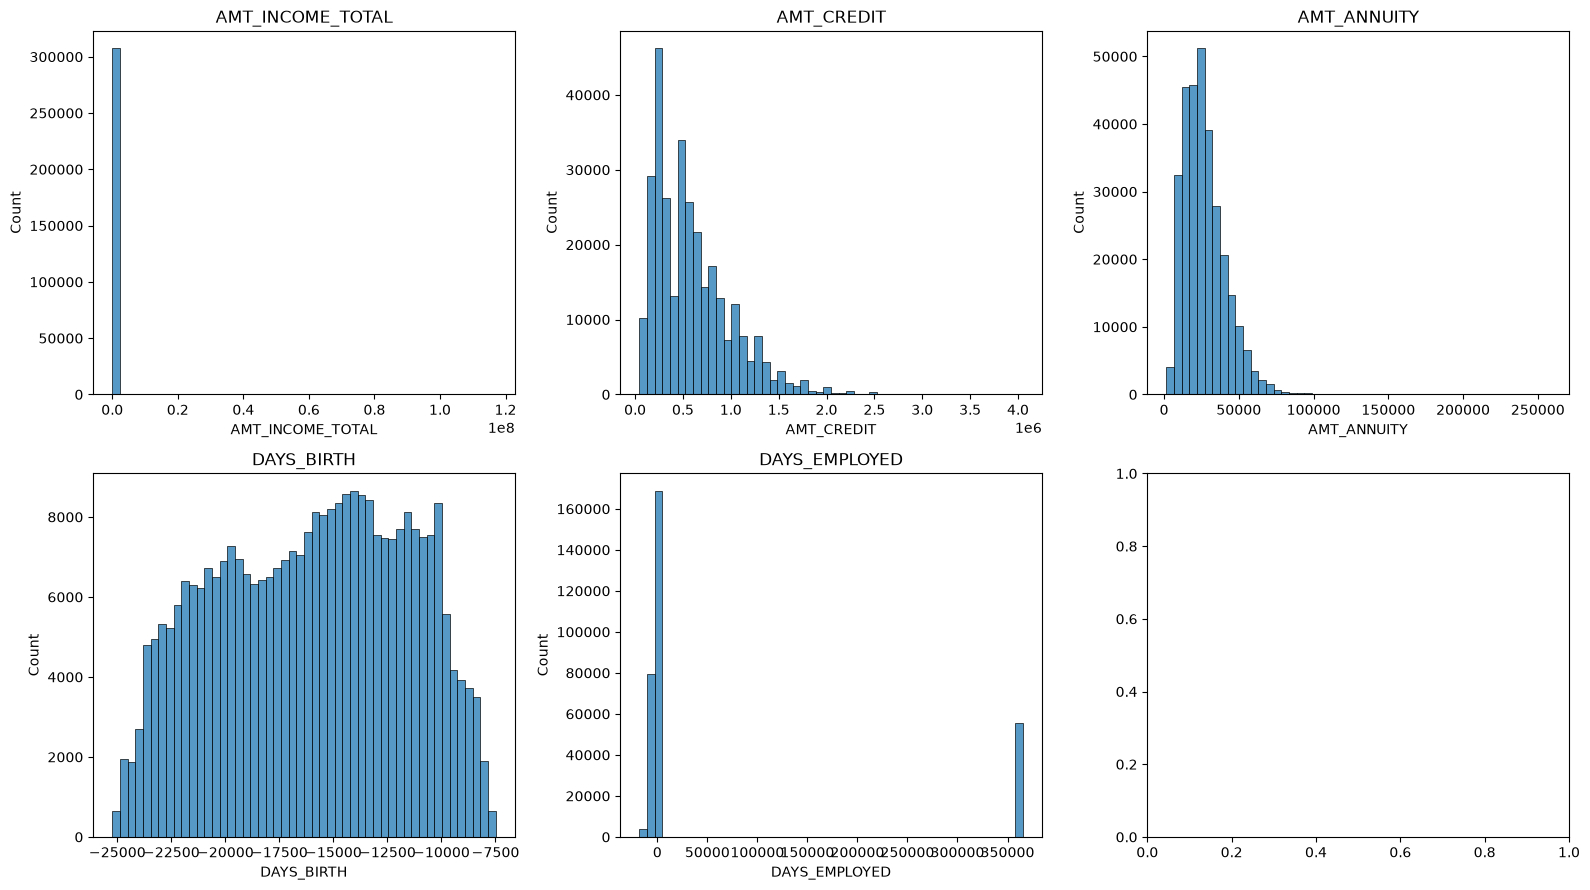

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

key_features = ["AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY", "DAYS_BIRTH", "DAYS_EMPLOYED"]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flatten(), key_features):
    sns.histplot(app[col].dropna(), bins=50, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.savefig("../reports/feature_distributions.png", dpi=150)
plt.show()

In [5]:
print((app["DAYS_EMPLOYED"] == 365243).sum(), "baris anomali")
app["DAYS_EMPLOYED_ANOM"] = app["DAYS_EMPLOYED"] == 365243
app["DAYS_EMPLOYED"] = app["DAYS_EMPLOYED"].replace(365243, np.nan)

55374 baris anomali


C:\Users\natanaelalbert\AppData\Local\Temp\ipykernel_30728\4190630962.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  app["DAYS_EMPLOYED_ANOM"] = app["DAYS_EMPLOYED"] == 365243


In [4]:
numeric_cols = app.select_dtypes(include=[np.number]).columns
correlations = app[numeric_cols].corr()["TARGET"].sort_values()

print("Korelasi negatif terkuat (menurunkan risiko):")
print(correlations.head(10))
print("\nKorelasi positif terkuat (meningkatkan risiko):")
print(correlations.tail(11)[:-1])  # exclude TARGET itself

Korelasi negatif terkuat (menurunkan risiko):
EXT_SOURCE_3                 -0.178919
EXT_SOURCE_2                 -0.160472
EXT_SOURCE_1                 -0.155317
DAYS_EMPLOYED                -0.044932
FLOORSMAX_AVG                -0.044003
FLOORSMAX_MEDI               -0.043768
FLOORSMAX_MODE               -0.043226
AMT_GOODS_PRICE              -0.039645
REGION_POPULATION_RELATIVE   -0.037227
ELEVATORS_AVG                -0.034199
Name: TARGET, dtype: float64

Korelasi positif terkuat (meningkatkan risiko):
DAYS_REGISTRATION              0.041975
FLAG_DOCUMENT_3                0.044346
REG_CITY_NOT_LIVE_CITY         0.044395
FLAG_EMP_PHONE                 0.045982
REG_CITY_NOT_WORK_CITY         0.050994
DAYS_ID_PUBLISH                0.051457
DAYS_LAST_PHONE_CHANGE         0.055218
REGION_RATING_CLIENT           0.058899
REGION_RATING_CLIENT_W_CITY    0.060893
DAYS_BIRTH                     0.078239
Name: TARGET, dtype: float64


In [6]:
bureau = pd.read_csv(RAW / "bureau.csv")

bureau_agg = bureau.groupby("SK_ID_CURR").agg(
    bureau_count=("SK_ID_BUREAU", "count"),
    bureau_active_count=("CREDIT_ACTIVE", lambda x: (x == "Active").sum()),
    bureau_overdue_count=("CREDIT_DAY_OVERDUE", lambda x: (x > 0).sum()),
    bureau_credit_sum=("AMT_CREDIT_SUM", "sum"),
    bureau_credit_sum_debt=("AMT_CREDIT_SUM_DEBT", "sum"),
    bureau_max_overdue=("AMT_CREDIT_MAX_OVERDUE", "max"),
).reset_index()

bureau_agg["bureau_overdue_ratio"] = (
    bureau_agg["bureau_overdue_count"] / bureau_agg["bureau_count"]
)

bureau_agg.shape

(305811, 8)

In [7]:
prev = pd.read_csv(RAW / "previous_application.csv")

prev_agg = prev.groupby("SK_ID_CURR").agg(
    prev_app_count=("SK_ID_PREV", "count"),
    prev_approved_count=("NAME_CONTRACT_STATUS", lambda x: (x == "Approved").sum()),
    prev_refused_count=("NAME_CONTRACT_STATUS", lambda x: (x == "Refused").sum()),
    prev_avg_credit=("AMT_CREDIT", "mean"),
).reset_index()

prev_agg["prev_approval_rate"] = (
    prev_agg["prev_approved_count"] / prev_agg["prev_app_count"]
)

prev_agg.shape

(338857, 6)

In [8]:
df = app.merge(bureau_agg, on="SK_ID_CURR", how="left")
df = df.merge(prev_agg, on="SK_ID_CURR", how="left")

# Nasabah tanpa riwayat di bureau/previous_application -> isi 0, bukan NaN
fill_zero_cols = [c for c in bureau_agg.columns if c != "SK_ID_CURR"] + \
                  [c for c in prev_agg.columns if c != "SK_ID_CURR"]
df[fill_zero_cols] = df[fill_zero_cols].fillna(0)

print(df.shape)

(307511, 135)


In [9]:
df["credit_income_ratio"] = df["AMT_CREDIT"] / df["AMT_INCOME_TOTAL"]
df["annuity_income_ratio"] = df["AMT_ANNUITY"] / df["AMT_INCOME_TOTAL"]
df["credit_annuity_ratio"] = df["AMT_CREDIT"] / df["AMT_ANNUITY"]
df["age_years"] = -df["DAYS_BIRTH"] / 365
df["employed_years"] = -df["DAYS_EMPLOYED"] / 365
df["employed_age_ratio"] = df["employed_years"] / df["age_years"]

C:\Users\natanaelalbert\AppData\Local\Temp\ipykernel_30728\1185895121.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["credit_income_ratio"] = df["AMT_CREDIT"] / df["AMT_INCOME_TOTAL"]
C:\Users\natanaelalbert\AppData\Local\Temp\ipykernel_30728\1185895121.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["annuity_income_ratio"] = df["AMT_ANNUITY"] / df["AMT_INCOME_TOTAL"]
C:\Users\natanaelalbert\AppData\Local\Temp\ipykernel_30728\1185895121.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the

In [10]:
df["age_group"] = pd.cut(
    df["age_years"], bins=[0, 25, 35, 45, 55, 100],
    labels=["<25", "25-35", "35-45", "45-55", "55+"]
)

C:\Users\natanaelalbert\AppData\Local\Temp\ipykernel_30728\1759383845.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["age_group"] = pd.cut(


In [11]:
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()
print(f"{len(cat_cols)} kolom kategorikal")

for col in cat_cols:
    df[col] = df[col].astype("category")

16 kolom kategorikal


C:\Users\natanaelalbert\AppData\Local\Temp\ipykernel_30728\446709525.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=["object"]).columns.tolist()


In [12]:
PROCESSED = PROJECT_ROOT / "data" / "processed"
PROCESSED.mkdir(exist_ok=True)
df.to_parquet(PROCESSED / "application_features.parquet", index=False)
print(f"Saved: {df.shape}")

Saved: (307511, 142)
